Preprocess customer data with cleaning and feature scaling.

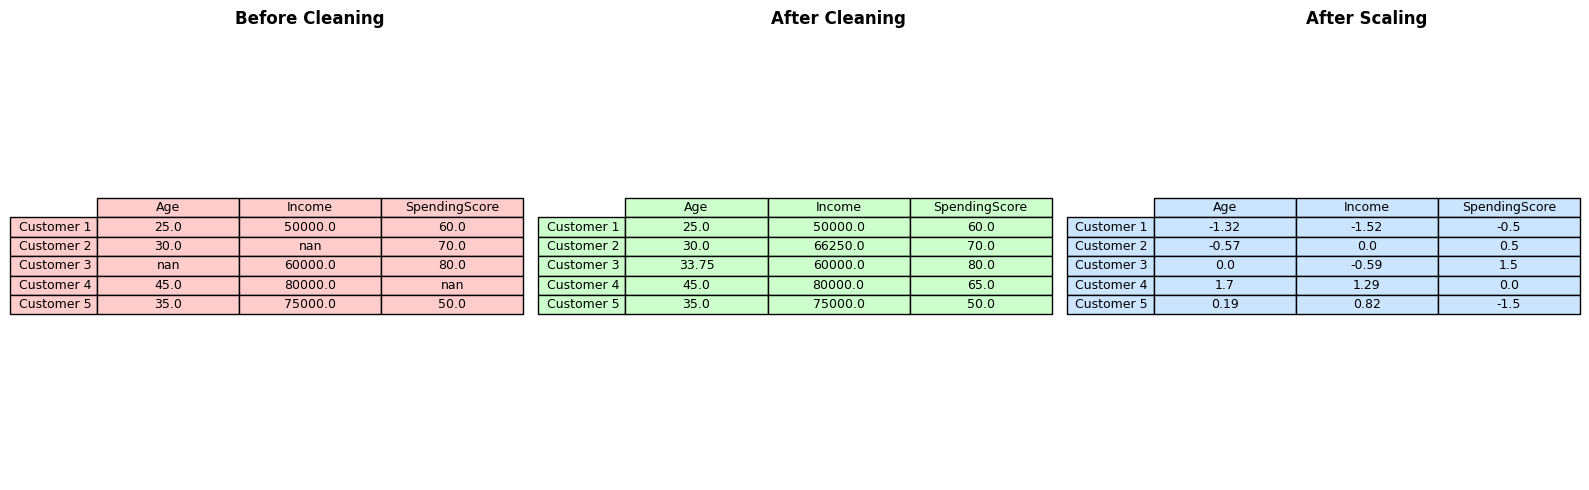

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------------------------
# 1. Sample customer dataset with missing values
# ---------------------------
data = {
    'Age': [25, 30, np.nan, 45, 35],
    'Income': [50000, np.nan, 60000, 80000, 75000],
    'SpendingScore': [60, 70, 80, np.nan, 50]
}
df = pd.DataFrame(data, index=[f"Customer {i}" for i in range(1, 6)])

# ---------------------------
# 2. Cleaning (Fill missing values with column mean)
# ---------------------------
df_cleaned = df.fillna(df.mean(numeric_only=True))

# ---------------------------
# 3. Scaling (Standardization)
# ---------------------------
scaler = StandardScaler()
scaled_array = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(scaled_array, columns=df_cleaned.columns, index=df.index)

# ---------------------------
# 4. Plot side-by-side colored tables
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Define colors
before_color = "#FFCCCC"   # light red
clean_color = "#CCFFCC"    # light green
scale_color = "#CCE5FF"    # light blue

def color_table(ax, data, title, color):
    ax.axis("off")
    table = ax.table(cellText=data.values.round(2),
                     rowLabels=data.index,
                     colLabels=data.columns,
                     loc="center",
                     cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    ax.set_title(title, fontsize=12, fontweight="bold")

    # Apply background color
    for key, cell in table.get_celld().items():
        cell.set_facecolor(color)
        cell.set_edgecolor("black")

# Plot tables
color_table(axes[0], df, "Before Cleaning", before_color)
color_table(axes[1], df_cleaned, "After Cleaning", clean_color)
color_table(axes[2], df_scaled, "After Scaling", scale_color)

plt.tight_layout()
plt.show()


In [ ]:
# ================================
# Preprocessing Customer Data
# ================================

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Step 2: Example customer dataset
data = {
    'Age': [25, 30, 45, 35, None, 40],
    'Income': [50000, 60000, None, 80000, 75000, 90000],
    'SpendingScore': [60, 70, 80, None, 50, 90]
}
df = pd.DataFrame(data)
print("Original Data:\n", df)

# Step 3: Handle missing values (Cleaning)
imputer = SimpleImputer(strategy='mean')
cleaned_data = imputer.fit_transform(df)
df_cleaned = pd.DataFrame(cleaned_data, columns=df.columns)
print("\nAfter Cleaning (Missing Values Filled):\n", df_cleaned)

# Step 4: Feature Scaling (Standardization: mean=0, std=1)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)
print("\nAfter Feature Scaling:\n", df_scaled)

# Step 5: Train-test split (optional step for modeling)
X_train, X_test = train_test_split(df_scaled, test_size=0.3, random_state=42)
print("\nTraining Data:\n", X_train)
print("\nTesting Data:\n", X_test)


Comparison

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# ==================== Explanation Block ====================
explanation_text = """
Explanation:
- For Regression tasks:
    -> MAE (Mean Absolute Error) is the correct metric. Lower MAE = better predictions.
    -> R² measures how much variance in the target variable is explained by the model.
- For Classification tasks:
    -> Precision is meaningful when false positives are costly (e.g., diagnosing a disease incorrectly).
    -> Recall is meaningful when false negatives are costly (e.g., missing an actual fraud).
- In Regression, it's normal to ignore precision/recall and focus on MAE and R².
"""

print(explanation_text)

# ==================== Synthetic Customer Data ====================
np.random.seed(42)
data = pd.DataFrame({
    "Age": np.random.randint(18, 70, 50),
    "Income": np.random.randint(20000, 100000, 50),
    "SpendingScore": np.random.randint(1, 100, 50)
})

# Introduce some missing values
data.loc[5, "Income"] = np.nan
data.loc[10, "SpendingScore"] = np.nan

# ---------------- Before Cleaning ----------------
X_raw = data.drop("SpendingScore", axis=1)
y_raw = data["SpendingScore"].fillna(0)

X_train, X_test, y_train, y_test = train_test_split(X_raw.fillna(0), y_raw, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_raw = model.predict(X_test)
mae_raw = mean_absolute_error(y_test, y_pred_raw)
r2_raw = r2_score(y_test, y_pred_raw)

# ---------------- After Cleaning ----------------
data_clean = data.fillna(data.mean(numeric_only=True))
X_clean = data_clean.drop("SpendingScore", axis=1)
y_clean = data_clean["SpendingScore"]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred_clean = model.predict(X_test)
mae_clean = mean_absolute_error(y_test, y_pred_clean)
r2_clean = r2_score(y_test, y_pred_clean)

# ---------------- After Scaling ----------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_clean, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred_scaled = model.predict(X_test)
mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

# ==================== Formulas ====================
print("\nFormulas:")
print("MAE = (1/n) * Σ | yᵢ - ŷᵢ |")
print("R² = 1 - [ Σ (yᵢ - ŷᵢ)² / Σ (yᵢ - ȳ)² ]")

# ==================== Results Table ====================
results = pd.DataFrame({
    "Stage": ["Before Cleaning", "After Cleaning", "After Scaling"],
    "MAE": [mae_raw, mae_clean, mae_scaled],
    "R²": [r2_raw, r2_clean, r2_scaled]
})

# Apply coloring
def color_table(val):
    if isinstance(val, str):
        return "background-color: lightblue; color: black; font-weight: bold;"
    return "background-color: salmon; color: black;"

styled_results = results.style.applymap(color_table)
styled_results



Explanation:
- For Regression tasks:
    -> MAE (Mean Absolute Error) is the correct metric. Lower MAE = better predictions.
    -> R² measures how much variance in the target variable is explained by the model.
- For Classification tasks:
    -> Precision is meaningful when false positives are costly (e.g., diagnosing a disease incorrectly).
    -> Recall is meaningful when false negatives are costly (e.g., missing an actual fraud).
- In Regression, it's normal to ignore precision/recall and focus on MAE and R².


Formulas:
MAE = (1/n) * Σ | yᵢ - ŷᵢ |
R² = 1 - [ Σ (yᵢ - ŷᵢ)² / Σ (yᵢ - ȳ)² ]


/tmp/ipython-input-1245739983.py:84: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_results = results.style.applymap(color_table)


,Stage,MAE,R²
0,Before Cleaning,29.779585,-0.017902
1,After Cleaning,31.184247,-0.094195
2,After Scaling,31.184247,-0.094195
